In [137]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from torch.nn import BCELoss
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

In [138]:
X_train = np.random.uniform(size=(1000,2))
yxor_train = np.logical_xor(np.round(X_train[:, 0]), np.round(X_train[:, 1])).astype(int).reshape(-1, 1)

values = np.linspace(0.0, 1.0, 101)
xx, yy = np.meshgrid(values, values)
grid = np.stack([xx, yy], axis=-1)
X_test = grid.reshape(-1, 2)
yxor_test = np.logical_xor(np.round(X_test[:, 0]), np.round(X_test[:, 1])).astype(int).reshape(-1, 1)

X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()
yxor_train = torch.from_numpy(yxor_train).float()

trainXOR_dataset = TensorDataset(X_train, yxor_train)
trainXOR_loader = DataLoader(trainXOR_dataset, batch_size=100)

In [139]:
loss_fn = BCELoss()

In [140]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(2, 4)
        self.linear2 = nn.Linear(4, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.sigmoid(self.linear2(x))
        return x


In [141]:
class MLP_WEIRD(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU()
        )
        self.layer2 = nn.Sequential(
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        return x


In [142]:
def train_one_epoch(model, optimizer, data_loader):
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(data_loader):
        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(data_loader)
    return avg_loss

In [143]:
def train_new_model(ModelClass, data_loader, epochs):
    model = ModelClass()

    # optimizer = torch.optim.SGD(model.parameters(), lr=0.1, nesterov=True, momentum=0.9)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

    model.train()

    for epoch in range(epochs):
        avg_loss = train_one_epoch(model, optimizer, data_loader)

        if epoch % 10 == 9:
            model.eval()
            with torch.no_grad():
                y_pred = model(X_test)
                y_pred = np.round(y_pred.detach().numpy())
                accuracy = accuracy_score(yxor_test, y_pred)
                print(f"  epoch {epoch} loss: {avg_loss} accuracy: {accuracy}")

            model.train()

    model.eval()

    return model


In [144]:
modelXOR = train_new_model(MLP, trainXOR_loader, 200)

  epoch 9 loss: 0.4367023199796677 accuracy: 0.704538770708754
  epoch 19 loss: 0.4207063317298889 accuracy: 0.7130673463385943
  epoch 29 loss: 0.41129876375198365 accuracy: 0.7170865601411627
  epoch 39 loss: 0.40557956993579863 accuracy: 0.7179688265856289
  epoch 49 loss: 0.4053018182516098 accuracy: 0.7229683364376042
  epoch 59 loss: 0.4014450550079346 accuracy: 0.7214978923634938
  epoch 69 loss: 0.3983208745718002 accuracy: 0.7233604548573669
  epoch 79 loss: 0.3972905158996582 accuracy: 0.7240466620919518
  epoch 89 loss: 0.3956467300653458 accuracy: 0.7246348397215959
  epoch 99 loss: 0.39509424567222595 accuracy: 0.7252230173512401
  epoch 109 loss: 0.39387249052524564 accuracy: 0.7244387805117145
  epoch 119 loss: 0.39336071312427523 accuracy: 0.7258111949808842
  epoch 129 loss: 0.3924719512462616 accuracy: 0.725909224585825
  epoch 139 loss: 0.391006788611412 accuracy: 0.7260072541907656
  epoch 149 loss: 0.39079607725143434 accuracy: 0.7257131653759435
  epoch 159 loss: 

In [145]:
model_weird = train_new_model(MLP_WEIRD, trainXOR_loader, 200)

  epoch 9 loss: 0.48017185032367704 accuracy: 0.6865013233996667
  epoch 19 loss: 0.46036627888679504 accuracy: 0.6885599451034212
  epoch 29 loss: 0.45268983840942384 accuracy: 0.6865013233996667
  epoch 39 loss: 0.44587439596652984 accuracy: 0.6913047740417606
  epoch 49 loss: 0.44047039151191714 accuracy: 0.6915988628565827
  epoch 59 loss: 0.4374582767486572 accuracy: 0.6949318694245662
  epoch 69 loss: 0.43524779975414274 accuracy: 0.6956180766591511
  epoch 79 loss: 0.432585871219635 accuracy: 0.6965003431036173
  epoch 89 loss: 0.4329971343278885 accuracy: 0.6965003431036173
  epoch 99 loss: 0.42985943555831907 accuracy: 0.6984609352024311
  epoch 109 loss: 0.42860465943813325 accuracy: 0.6986569944123125
  epoch 119 loss: 0.42756501734256747 accuracy: 0.699147142437016
  epoch 129 loss: 0.4256172180175781 accuracy: 0.7000294088814822
  epoch 139 loss: 0.4244790405035019 accuracy: 0.7010097049308891
  epoch 149 loss: 0.42374164164066314 accuracy: 0.7014018233506519
  epoch 159 l

0.7261052837957063


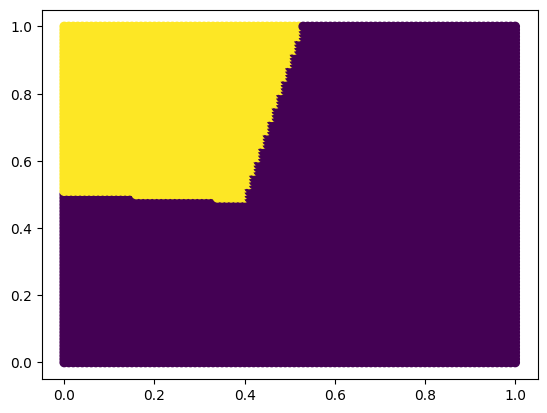

In [146]:
y_pred = modelXOR(X_test)
y_pred = np.round(y_pred.detach().numpy())
print(accuracy_score(yxor_test, y_pred))

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)